#fMRI Data - The General Linear Model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

Main parameters of the fMRI scan and experimental desgin.

In [4]:
# Import the data for slice 36
data = np.genfromtxt('slice_36.csv', delimiter=',')

In [5]:
block_design    = ['rest', 'stim']  #patron temporal del experimento, rest=reposo , stim = estimulo
block_size      = 6 #volumenes o tiempoints del bloque rest/stim
block_RT        = 7 #rt = repetition time - segundos entre una adquisición de volumen y la siguiente.
block_total     = 16 #bloques en total

block_length    = block_size*block_RT  #Duracion de un bloque
acq_num         = block_size*block_total  #numero total de volumenes en el experimento
data_time       = block_length*block_total  #tiempo total REAL en segundos
data_time_vol   = np.arange(acq_num)*block_RT #tiempo real del volumen(correccion eje X)

#dimensiones espaciales del corte
x_size = 64
y_size = 64

#reshape
data_ordered = data.reshape(x_size,y_size,acq_num)
print(data_ordered.shape)

# Calculate the mean signal for each voxel
mean_data = data_ordered.mean(axis=2)

(64, 64, 96)


Desing Matrix, which represents our hypothesis of how the brain responds to the auditory stimulation.

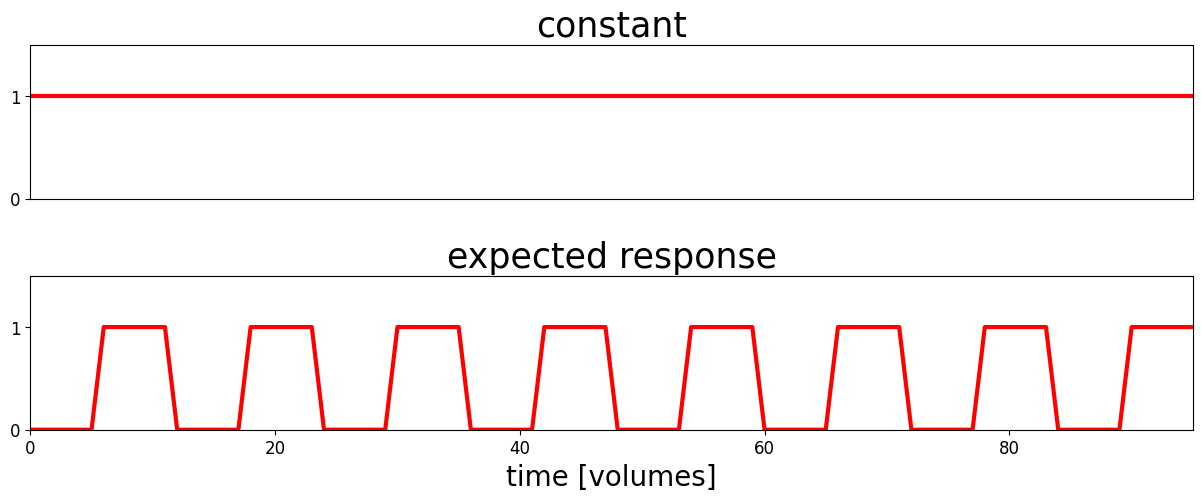

In [7]:
# Create the design matrix
constant = np.ones(acq_num)
rest     = np.zeros(block_size)
stim     = np.ones(block_size)
block    = np.concatenate((rest, stim), axis=0)
predicted_response = np.tile(block, int(block_total/2))

design_matrix = np.array((constant, predicted_response))

# Create the plots
fig, ax = plt.subplots(2,1, figsize=(15, 5))
ax[0].plot(design_matrix[0], c= "red", lw=3)
ax[0].set_xlim(0, acq_num-1)
ax[0].set_ylim(0, 1.5)
ax[0].set_title('constant',  fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([0,1])
ax[0].tick_params(labelsize=12)
ax[0].tick_params(labelsize=12)

ax[1].plot(design_matrix[1],c= "red", lw=3)
ax[1].set_xlim(0, acq_num-1)
ax[1].set_ylim(0, 1.5)
ax[1].set_title('expected response', fontsize=25)
ax[1].set_yticks([0,1])
ax[1].set_xlabel('time [volumes]', fontsize=20)
ax[1].tick_params(labelsize=12)
ax[1].tick_params(labelsize=12)

fig.subplots_adjust(wspace=0, hspace=0.5)
plt.show()

##Completed GML

In the previous notebook we only used the second part of the design matrix for our correlation map but for the GLM analysis we need also the constant part. In the following we will implement the GLM as a function called do_GLM. The details about the GLM can be found in the corresponding medium article.

In [10]:
def do_GLM(X, y):  # X: Desing matrix , y: observed data

    # Make sure design matrix has the right orientation
    if X.shape[1] > X.shape[0]:
        X = X.transpose()


    """ *Ordinary least squares (OLS)"""
    tmp   = np.linalg.inv(X.transpose().dot(X))
    tmp   = tmp.dot(X.transpose())

    # Pre-allocate variables
    beta  = np.zeros((y.shape[0], X.shape[1]))
    e     = np.zeros(y.shape)
    model = np.zeros(y.shape)
    r     = np.zeros(y.shape[0])

    # Find beta values for each voxel and calculate the model, error and the correlation coefficients
    for i in range(y.shape[0]):
        beta[i]  = tmp.dot(y[i,:].transpose())  #obtainig the beta values for each voxel
        model[i] = X.dot(beta[i])  #signal reconstruction based in beta
        e[i]     = (y[i,:] - model[i]) #error, difference between measurements: model and real data
        r[i]     = np.sqrt(model[i].var()/y[i,:].var()) #**Coefficient of determination

    return beta, model, e, r

*La formula clásica de mínimos cuadrados ordinarios (Ordinary Least Squares) es la forma estándar de resolver un GLM:

$$\hat{\beta} = (X^T X)^{-1} X^T y$$

Traduciendo cada pieza a código:

- X.transpose() → $X^T$ (la matriz de diseño transpuesta).
- X.transpose().dot(X) → $X^T X$ (producto matricial, .dot() es el método de NumPy para multiplicación de matrices, distinto de * que sería multiplicación elemento porelemento).
- np.linalg.inv(...) → $(X^T X)^{-1}$ (la matriz inversa).
- tmp.dot(X.transpose()) → multiplica ese resultado por $X^T$ nuevamente, completando $(X^T X)^{-1} X^T$.

**El coeficiente de determinacion, compara cuánta varianza tiene la señal predicha por el modelo contra cuánta varianza tiene la señal real observada. Si el modelo explica casi toda la variabilidad de la señal real, este ratio se acerca a 1; si el modelo no explica casi nada, se acerca a 0.

##Maps for Correlation Analysis

In [11]:
beta, model, e, r = do_GLM(design_matrix, data)

r = r.reshape(x_size,y_size)
map = r.copy()
map[map<0.35] = np.nan

[]

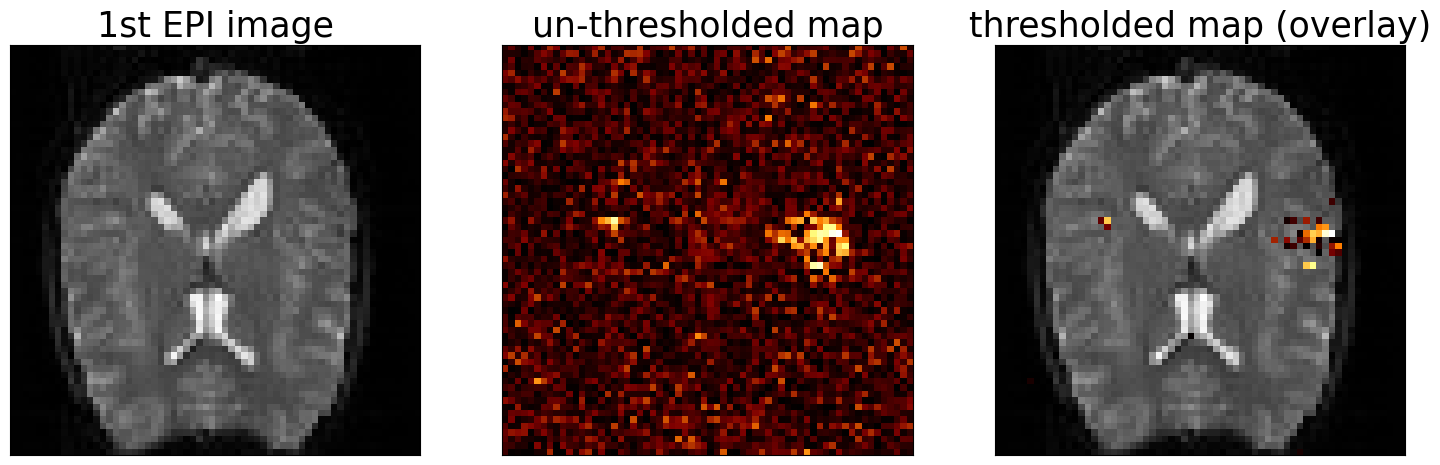

In [12]:
fig, ax = plt.subplots(1,3,figsize=(18, 6))

ax[0].imshow(mean_data, cmap='gray')
ax[0].set_title('1st EPI image', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].imshow(r, cmap='afmhot')
ax[1].set_title('un-thresholded map', fontsize=25)
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].imshow(mean_data, cmap='gray')
ax[2].imshow(map, cmap='afmhot')
ax[2].set_title('thresholded map (overlay)', fontsize=25)
ax[2].set_xticks([])
ax[2].set_yticks([])

##Third regressor
Lets take the average response of all voxels above threshold from above as third regressor (**add one more column to the desing matrix**). Therefore we need to zscore the data and sclae it as follows.

Despues de identificar el grupo de vóxeles que parecen responder al estímulo, los que pasaron el threshold, su promedio probablemente va a ser una representación más realista de cómo se ve la verdadera respuesta hemodinámica en este cerebro específico en vez de la onda cuadrada idealizada que asumimos al principio. Es decir, pasamos de un regresor teórico (lo que creemos que debería pasar) a un regresor empírico (lo que realmente pasó, promediado de los vóxeles con mejor evidencia).

Z-score (o puntuación estandarizada) es una forma de transformar cualquier conjunto de números para que queden en una escala común: media = 0, desviación estándar = 1. Permitiendo así comparar o combinar variables que originalmente están en escalas muy distintas.

La fórmula es simple:

$$z = \frac{x - \mu}{\sigma}$$
x: tu valor original.
μ (mu): la media de todo el conjunto de datos.
σ (sigma): la desviación estándar de todo el conjunto.

Si un valor es igual a la media, su z-score es 0. Si un valor está una desviación estándar por encima de la media, su z-score es 1. Si está dos desviaciones estándar por debajo, su z-score es -2. Es decir, el z-score te dice **qué tan lejos está este valor de lo normal/típico, medido en unidades de desviación estándar**


La matriz de diseño tiene:
- constant: todo en 1.
- predicted_response: valores entre 0 y 1.

El promedio real de intensidad de los vóxeles activos están en la escala de intensidad de MRI. Al agregarlo como un tercer regresor, se debe llevar a una escala comparable a la de la matriz de diseño, para que su magnitud no domine o distorsione el ajuste del modelo. Por eso se debe aplicar z-score a los datos.

In [13]:
#Normalizacion min-max
"""el valor mínimo del array se convierte en 0, el máximo en 1,
todo lo demás se distribuye proporcionalmente entre esos dos extremos"""
def scale(data):
    return (data - data.min()) / (data.max() - data.min())


#Normalizacion z- score
def z_score(data):
    mean = data.mean(axis=1, keepdims=True)
    std = data.std(axis=1, keepdims=True)
    norm_data = (data-mean)/std
    return norm_data


avg = z_score(data_ordered[~np.isnan(map),:])  #*seleccion de voxeles activos
avg = np.transpose(avg).mean(axis=1) #promedio atravez de los voxeles (axis =1 promedia atravez d elas columnas)
avg = scale(avg) #re-escalado a 0-1


"""al final, el nuevo regresor queda en una escala comparable a predicted_response,
 no solo "estandarizado" sino en el mismo rango visual/numérico."""
design_matrix = np.array((constant, predicted_response, avg))

- np.isnan(map): genera un array booleano del mismo tamaño que map, con True donde hay NaN (vóxeles descartados, baja correlación) y False donde hay un número real (vóxeles que sí superaron el umbral).
- ~: el operador de negación en NumPy,  invierte el booleano. ~np.isnan(map) da True exactamente donde SÍ hay un número válido (los vóxeles activos)
- data_ordered[~np.isnan(map), :]: esto es indexado booleano. Selecciona, de data_ordered, solo las filas (vóxeles) donde la condición es True. El resultado es un array más pequeño que el original, conteniendo únicamente el timecourse completo de los vóxeles que superaron el threshold en el mapa de correlación.

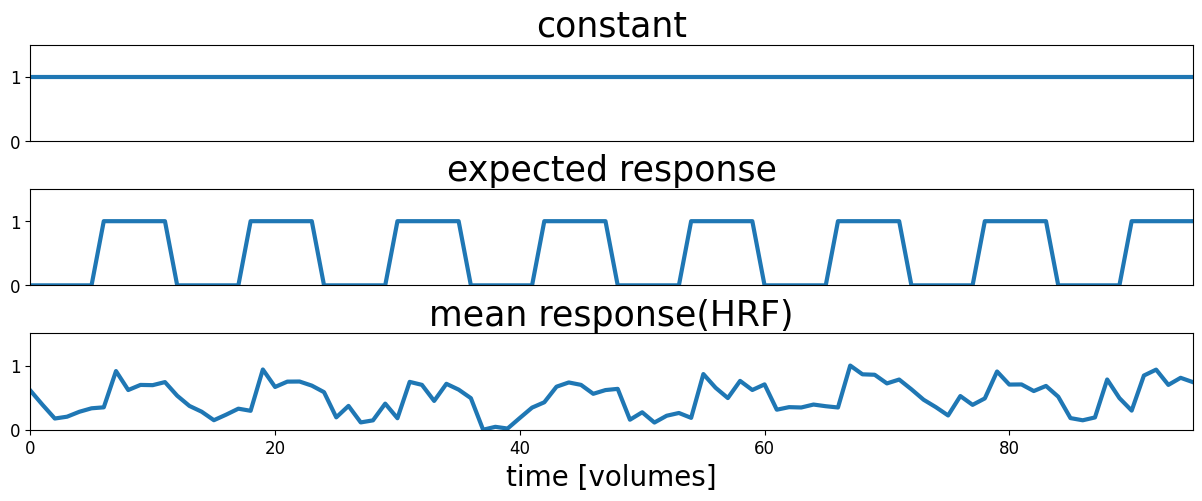

In [15]:
# Create the plots
fig, ax = plt.subplots(3,1, figsize=(15, 5))
ax[0].plot(design_matrix[0], lw=3)
ax[0].set_xlim(0, acq_num-1)
ax[0].set_ylim(0, 1.5)
ax[0].set_title('constant', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([0,1])
ax[0].tick_params(labelsize=12)
ax[0].tick_params(labelsize=12)

ax[1].plot(design_matrix[1], lw=3)
ax[1].set_xlim(0, acq_num-1)
ax[1].set_ylim(0, 1.5)
ax[1].set_title('expected response', fontsize=25)
ax[1].set_yticks([0,1])
ax[1].set_xticks([])
ax[1].tick_params(labelsize=12)
ax[1].tick_params(labelsize=12)

ax[2].plot(design_matrix[2], lw=3)
ax[2].set_xlim(0, acq_num-1)
ax[2].set_ylim(0, 1.5)
ax[2].set_title('mean response(HRF)', fontsize=25)
ax[2].set_yticks([0,1])
ax[2].set_xlabel('time [volumes]', fontsize=20)
ax[2].tick_params(labelsize=12)
ax[2].tick_params(labelsize=12)

fig.subplots_adjust(wspace=0, hspace=0.5)
plt.show()

**Hemodynamic Response Function(HRF)**

Es la forma típica que tiene la señal BOLD cuando el cerebro responde a un estímulo breve. No es instantánea ni cuadrada, tiene una curva característica y determina la secuencia temporal real.

El regresor empírico (avg) construido al promediar el comportamiento real de los vóxeles ya identificados como activos, captura naturalmente la forma de la HRF real, sin que tener que modelarla matemáticamente. Por eso ese tercer regresor es una mejora respecto a usar solo la onda cuadrada idealizada: refleja mejor cómo el cerebro realmente responde en el tiempo, en vez de asumir una respuesta instantánea que sabemos que es irreal.

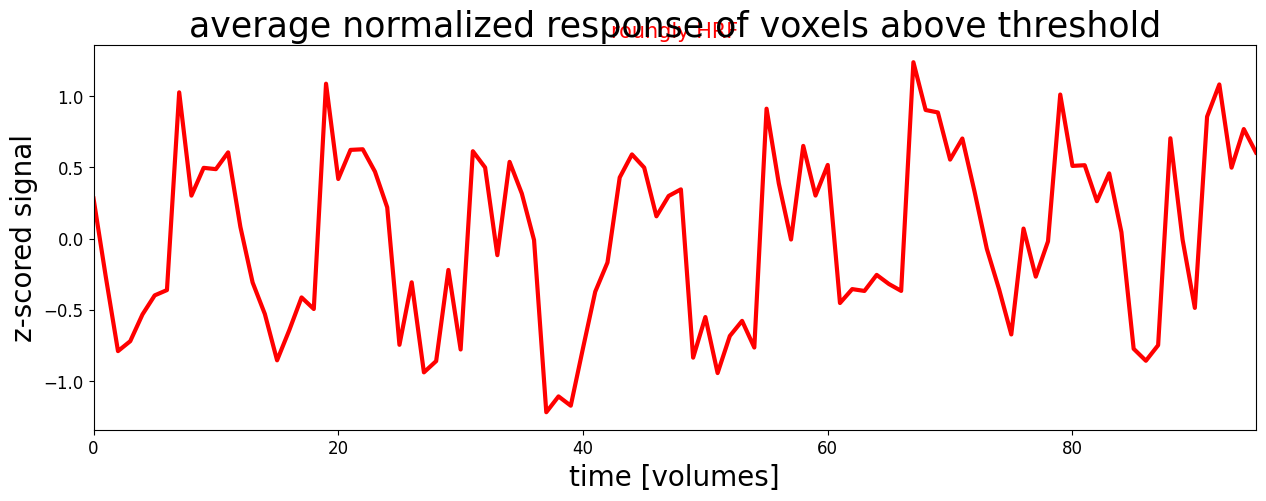

In [38]:
#isualize the mean response again
avg = z_score(data_ordered[~np.isnan(map),:])

# and plot the result
fig, ax = plt.subplots(1,1,figsize=(15, 5))

ax.plot(np.transpose(avg).mean(axis=1), c = "red", lw=3)
ax.set_title('average normalized response of voxels above threshold', fontsize=25)
ax.text(0.5, 1.02, "rouhgly HRF",transform=ax.transAxes,   ha="center", fontsize=15, color="red")
ax.set_xlim(0, acq_num-1)
ax.set_xlabel('time [volumes]', fontsize=20)
ax.set_ylabel('z-scored signal', fontsize=20)
ax.tick_params(labelsize=12)

plt.show()

##Spatial Smoothing
Lets construct the Gaussian kernel and the 2D convolution funtion.


The **gaussian filter** is the firts step in spatial smoothing. El suavizado espacial es una técnica estándar en el preprocesamiento de fMRI, se aplica un filtro que difumina ligeramente cada corte de la imagen, promediando cada vóxel con sus vecinos cercanos. Esto se hace para reducir ruido y mejorar la relación señal-ruido, a costa de perder algo de resolución espacial.



>>TAKEN FROM: http://subsurfwiki.org/wiki/Gaussian_filter


In [26]:
def gaussian_kernel(size, size_y=None): #(size, size_y=None): tamaño del filtro
    size = int(size)
    if not size_y:
        size_y = size
    else:
        size_y = int(size_y)


    x, y = np.mgrid[-size:size+1, -size_y:size_y+1] #grid
    g = np.exp(-(x**2/float(size)+y**2/float(size_y))) #Campana de gauss
    return g / g.sum() #normalizacion

In [27]:
 # Make the Gaussian by calling the function
gaussian_kernel_array = gaussian_kernel(8)

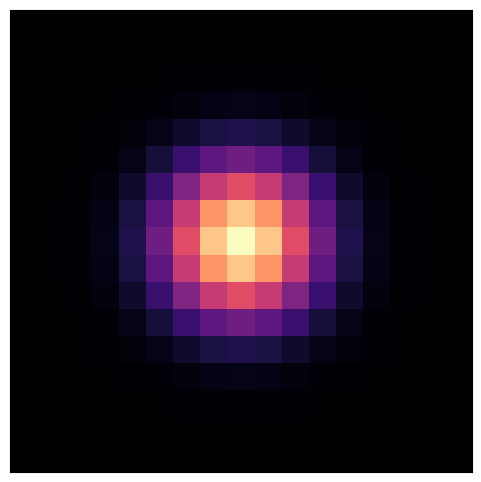

In [28]:
fig, ax = plt.subplots(1, 1, figsize=[6, 6])
ax.imshow(gaussian_kernel_array, cmap='magma', interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

la función de convolución aplica este kernel sobre una imagen real.

>> Adapted from: http://machinelearninguru.com/computer_vision/basics/convolution/image_convolution_1.html

In [29]:
def conv_image(image, input_kernel):
    # Flip the kernel (180°)
    kernel = np.flipud(np.fliplr(input_kernel))

    # Create output array
    output = np.zeros_like(image)

    # Determine size parameters
    m, n = kernel.shape[0]-1, kernel.shape[1]-1
    M, N = int((m/2)), int((n/2))

    # Add zero padding to the input image (limites de la imagen)
    image_padded = np.zeros((image.shape[0] + m, image.shape[1] + n))
    image_padded[M:-M, N:-N] = image

    #*Convolution
    for x in range(image.shape[1]):     # Loop over every pixel of the image
        for y in range(image.shape[0]):
            # element-wise multiplication of the kernel and the image

            output[y,x]=(kernel*image_padded[y:y +m+1, x:x +n+1]).sum()
            #output[y,x]=(kernel*image_padded[y:y +m+1, x:x +n+1]).mean()

    return output

*Convolution

Para cada posición (y, x) de la imagen original (recorriendo todas las filas y columnas):

- image_padded[y:y+m+1, x:x+n+1]: extrae un "parche" de la imagen con padding, del mismo tamaño que el kernel (17×17), centrado (gracias al padding) en la posición correspondiente a (y, x) de la imagen original.
- kernel * image_padded: multiplicación elemento por elemento (no multiplicación matricial — aquí no se usa .dot()) entre el kernel y el parche de imagen. Cada valor del kernel pondera al vóxel correspondiente del parche — los valores centrales del kernel (altos, por la forma de campana) pesan más que los de los bordes (bajos).
- .sum(): suma todos esos productos ponderados en un solo número — ese número se convierte en el nuevo valor del vóxel (y, x) en la imagen de salida.

Esto es un promedio ponderado localizado: cada vóxel de salida es una combinación de sus vecinos originales, donde los vecinos más cercanos al centro pesan más (por la forma gaussiana) que los más lejanos, produciendo el efecto de suavizado o difuminado.

In [35]:
gaussian_kernel_array = gaussian_kernel(4)
smoothed_mean_data = conv_image(mean_data, gaussian_kernel_array)

**Echo Planar Imaging(EPI)** es la técnica de adquisición rápida usada típicamente para capturar las imágenes funcionales de fMRI, EPI es el nombre técnico de la secuencia que usa el escáner para tomar estas fotos rápido.

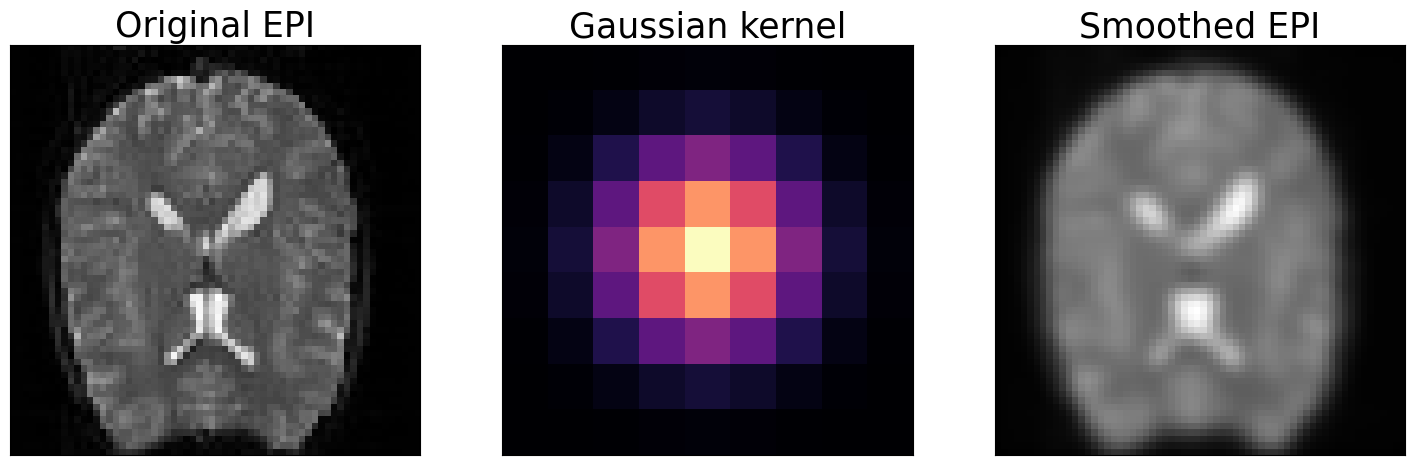

In [36]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

ax[0].imshow(mean_data, cmap='gray')
ax[0].set_title('Original EPI', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([])

ax[1].imshow(gaussian_kernel_array, cmap='magma', interpolation='nearest')
ax[1].set_title('Gaussian kernel', fontsize=25)
ax[1].set_xticks([])
ax[1].set_yticks([])

ax[2].imshow(smoothed_mean_data, cmap='gray')
ax[2].set_title('Smoothed EPI', fontsize=25)
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.show()

##Create the GLM on the smoothed data


In [39]:
gaussian_kernel_array = gaussian_kernel(3)

#suavizar cada volumen temporal
data_smoothed = np.zeros_like(data_ordered)
for i in range(data_ordered.shape[2]):
    data_smoothed[:,:,i] = conv_image(data_ordered[:,:,i], gaussian_kernel_array)

#Reshape
data_smoothed = data_smoothed.reshape(x_size * y_size, acq_num)

#GLM sobre la desing matrix con 3 regresores y los datos suavizados
beta, model, e, r = do_GLM(design_matrix, data_smoothed)

#treshold definition
r = r.reshape(x_size,y_size)
map = r.copy()
map[map<0.35] = np.nan


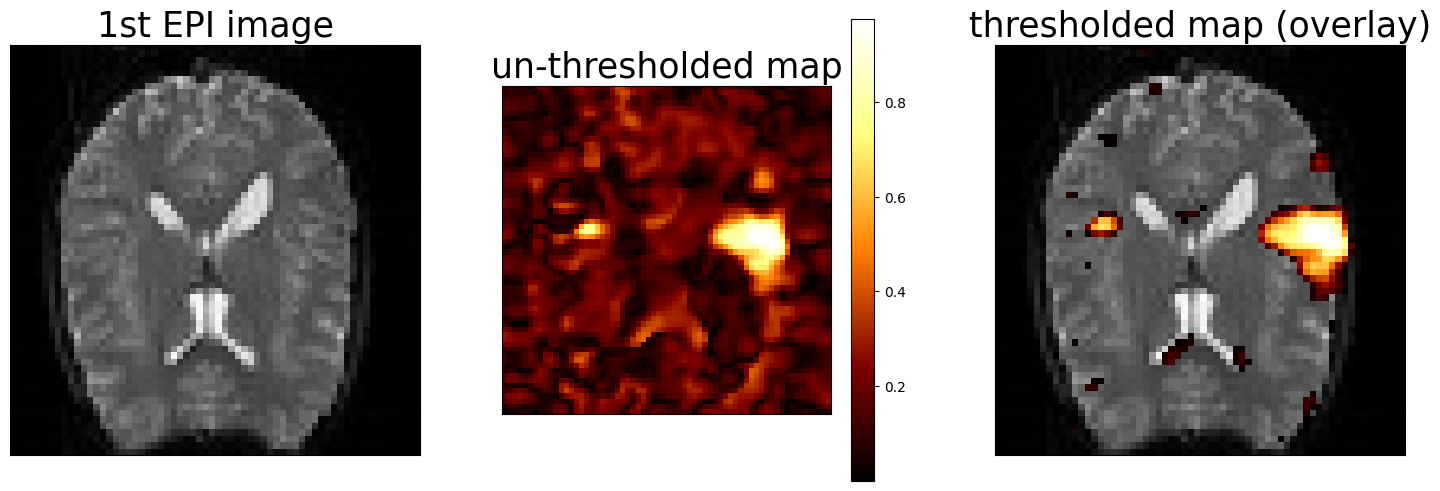

In [41]:
fig, ax = plt.subplots(1,3,figsize=(18, 6))

ax[0].imshow(mean_data, cmap='gray')
ax[0].set_title('1st EPI image', fontsize=25)
ax[0].set_xticks([])
ax[0].set_yticks([])

im1 = ax[1].imshow(r,  cmap='afmhot')
ax[1].imshow(r, cmap='afmhot')
ax[1].set_title('un-thresholded map', fontsize=25)
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.colorbar(im1, ax=ax[1])

ax[2].imshow(mean_data, cmap='gray')
ax[2].imshow(map, cmap='afmhot')
ax[2].set_title('thresholded map (overlay)', fontsize=25)
ax[2].set_xticks([])
ax[2].set_yticks([])

plt.show()

Finaly lets calculate and plot the maos for multiple slices...

In [52]:
!git clone https://github.com/SoffMoscoso/MRI-data-analysis
#Since my github repository

fatal: destination path 'MRI-data-analysis' already exists and is not an empty directory.


In [53]:
data_path = "/content/MRI-data-analysis/fMRI data analysis/cvs_data"
files = sorted(os.listdir(data_path))

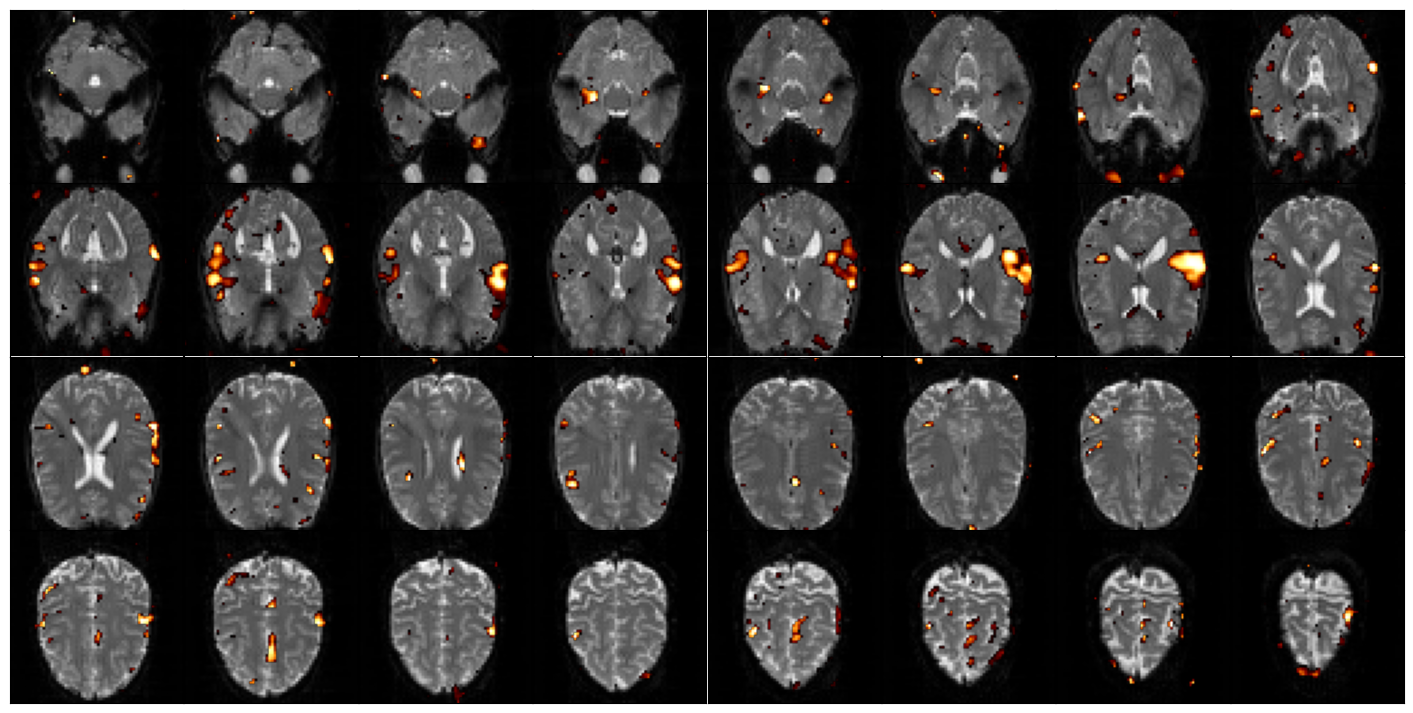

In [54]:
n=0
m=0
fig, ax = plt.subplots(4, 8,figsize=(18, 9)) #Graficar 32 SLICES

for i in files[23:55]:
    data = np.genfromtxt(os.path.join(data_path, i), delimiter=',') #seleccion de slice

    data_ordered = data.reshape(x_size,y_size,acq_num)  #reshape
    mean_data = data_ordered.mean(axis=2)  #mean EPI

    gaussian_kernel_array = gaussian_kernel(3) #kernel

    data_smoothed = np.zeros_like(data_ordered)  #smoothed EPI
    for i in range(data_ordered.shape[2]):
        data_smoothed[:,:,i] = conv_image(data_ordered[:,:,i], gaussian_kernel_array)

    data_smoothed = data_smoothed.reshape(x_size * y_size, acq_num)  #reshape smoothed EPI
    beta, model, e, r = do_GLM(design_matrix, data_smoothed)  #GML



    r = r.reshape(x_size,y_size)
    map = r.copy()
    map[map<0.35] = np.nan

    #ax[n].set_title('Thresholded GLM activation map overlay')
    ax[n][m].set_xticks([])
    ax[n][m].set_yticks([])
    ax[n][m].imshow(mean_data, cmap='gray')
    ax[n][m].imshow(map, cmap='afmhot')

    if m==7:
        n +=1
        m = 0
    else:
        m +=1

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

Esta parte nos permitio conocer la forma en la que actua el modelo lineal general (GLM) de correlacion de forma mas precisa y rigurosa, para explorar los voxeles estimulados en el intervalo de tiempo y conocer una aproximacion de la señal real de la respuesta hemodinamica del cerebro bajo un estimulo(HRF). Ademas, aplicando el kernel gaussiano, el resultado nos acerca a una visualizacion mas amena y usada de forma estandar en el analisis medico.

**Limitaciones**
- El umbral de r > 0.35 fue elegido empíricamente (por inspección visual), no mediante una corrección estadística formal por comparaciones múltiples, con miles de vóxeles evaluados, es esperable cierto número de falsos positivos solo por azar.

- La implementación de convolución y GLM se hizo desde cero con fines didácticos, lo cual es valioso para entender el mecanismo, pero en un pipeline real de investigación se usarían herramientas optimizadas y validadas (SPM, FSL, nilearn) tanto por eficiencia como por rigor metodológico ya establecido en la comunidad.
- El regresor empírico (avg) se derivó de un solo corte (el 36) y se reutilizó para todos los demás, una simplificación razonable, pero que asume que la forma de la respuesta hemodinámica es uniforme a travez de todo el cerebro, lo cual no es necesariamente cierto en la práctica